<a href="https://colab.research.google.com/github/parthakk07/Predicting-Student-Health-Risk/blob/main/final_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s6e7_path = kagglehub.competition_download('playground-series-s6e7')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [ ]:
from numpy._core.numeric import dtype
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

In [ ]:
df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
df.sample(4)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
263043,263043,at-risk,4.94,78.9,17.12,2221.0,10403.0,24.9,1.80,veg,low,average,sedentary,NaN,other
109100,109100,at-risk,8.73,97.0,24.73,2343.0,11856.0,43.1,NaN,veg,high,average,moderate,occasional,female
371827,371827,at-risk,7.19,75.9,22.52,1894.0,3812.0,23.6,2.66,non-veg,high,good,moderate,occasional,female
511093,511093,at-risk,8.21,79.2,21.25,2639.0,13109.0,44.8,2.15,veg,medium,good,moderate,yes,other


In [ ]:
df.drop("id",inplace=True,axis=1)

In [ ]:
df.sample(5)

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
192893,at-risk,8.20,77.1,21.74,2440.0,1284.0,30.3,2.39,veg,high,NaN,sedentary,yes,other
660283,at-risk,8.17,76.0,23.44,2301.0,2974.0,20.2,2.83,veg,NaN,good,sedentary,no,male
422651,at-risk,9.97,78.4,24.97,2614.0,13298.0,50.2,3.34,NaN,medium,NaN,active,yes,other
335841,at-risk,8.38,70.8,21.94,1776.0,5271.0,30.4,2.37,veg,low,good,sedentary,yes,other
411086,at-risk,7.45,72.3,27.05,1699.0,5605.0,20.5,1.52,non-veg,low,good,sedentary,yes,female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  object 
 1   sleep_duration           614089 non-null  float64
 2   heart_rate               682255 non-null  float64
 3   bmi                      676190 non-null  float64
 4   calorie_expenditure      637235 non-null  float64
 5   step_count               676172 non-null  float64
 6   exercise_duration        683187 non-null  float64
 7   water_intake             646611 non-null  float64
 8   diet_type                683187 non-null  object 
 9   stress_level             607277 non-null  object 
 10  sleep_quality            631757 non-null  object 
 11  physical_activity_level  653467 non-null  object 
 12  smoking_alcohol          661506 non-null  object 
 13  gender                   668715 non-null  object 
dtypes: f

In [ ]:
df.isnull().mean()*100

health_condition            0.000000
sleep_duration             11.012943
heart_rate                  1.135073
bmi                         2.013946
calorie_expenditure         7.658878
step_count                  2.016554
exercise_duration           1.000017
water_intake                6.300211
diet_type                   1.000017
stress_level               12.000064
sleep_quality               8.452690
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
dtype: float64

In [ ]:
df.describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='health_condition', ylabel='Count'>

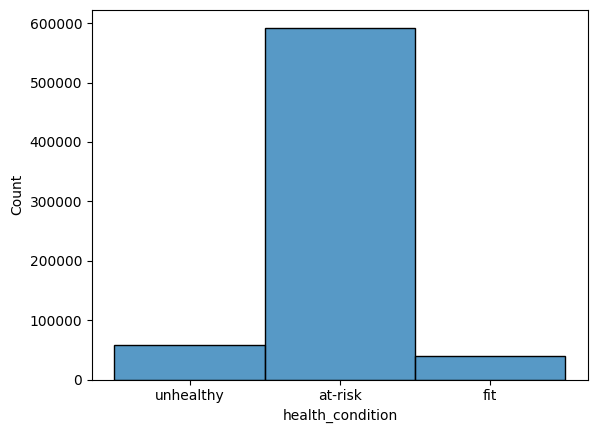

In [ ]:
sns.histplot(df["health_condition"])

<Axes: xlabel='diet_type', ylabel='Count'>

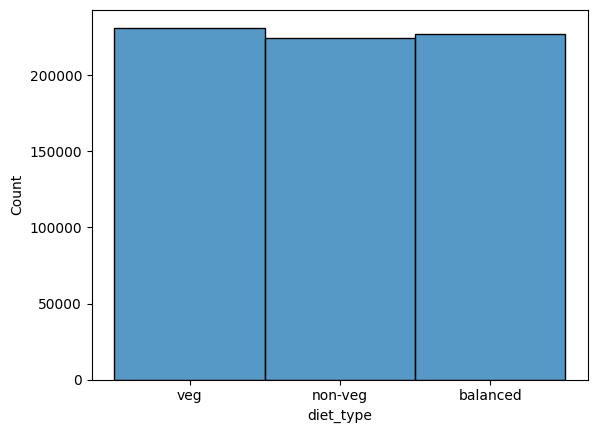

In [ ]:
sns.histplot(df["diet_type"])

<Axes: xlabel='sleep_quality', ylabel='Count'>

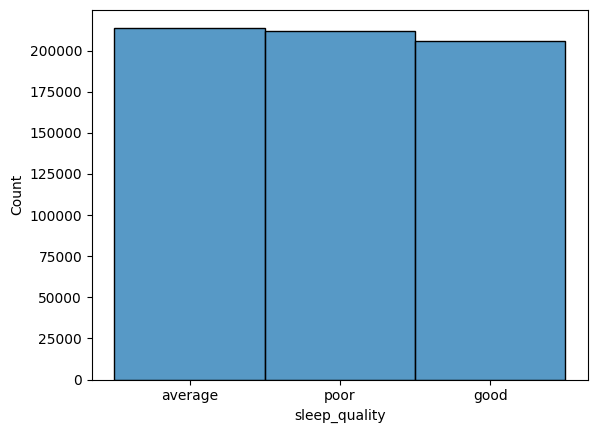

In [ ]:
sns.histplot(df["sleep_quality"])

<Axes: xlabel='stress_level', ylabel='Count'>

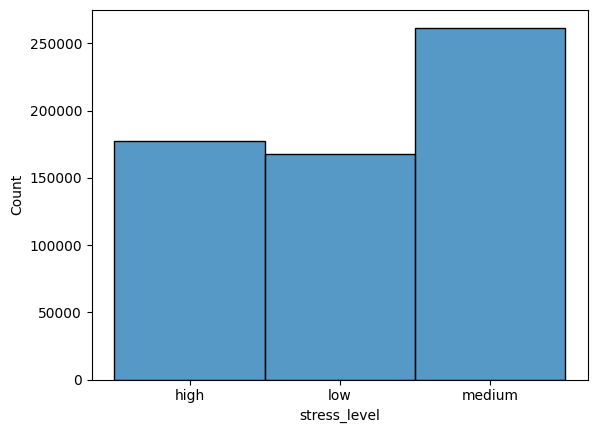

In [ ]:
sns.histplot(df["stress_level"])

<Axes: xlabel='sleep_duration', ylabel='Density'>

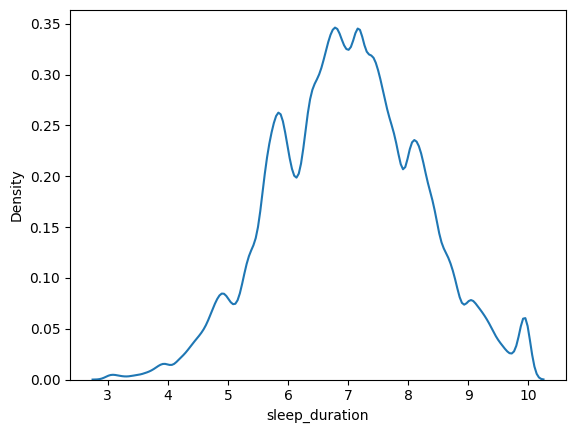

In [ ]:
sns.kdeplot(df["sleep_duration"])

<Axes: xlabel='calorie_expenditure', ylabel='Density'>

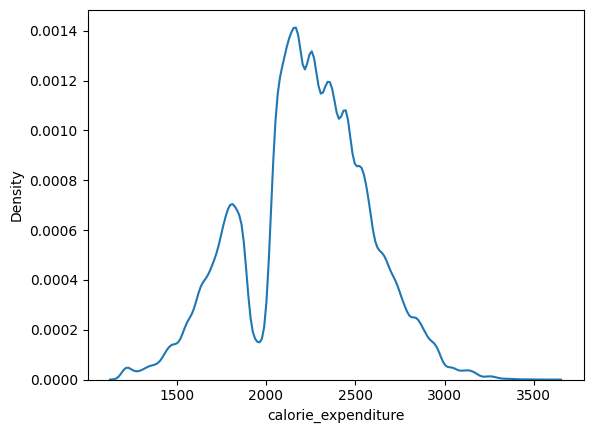

In [ ]:
sns.kdeplot(df["calorie_expenditure"])

<Axes: xlabel='step_count', ylabel='Density'>

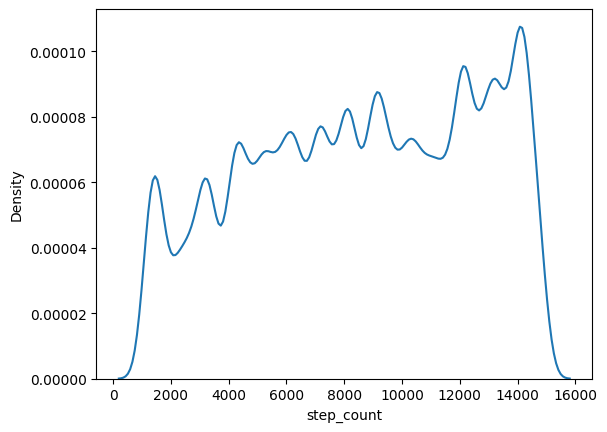

In [ ]:
sns.kdeplot(df["step_count"])

<Axes: xlabel='exercise_duration', ylabel='Density'>

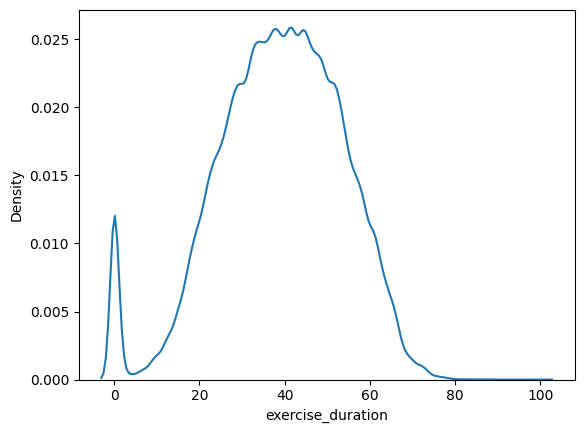

In [ ]:
sns.kdeplot(df["exercise_duration"])

<Axes: >

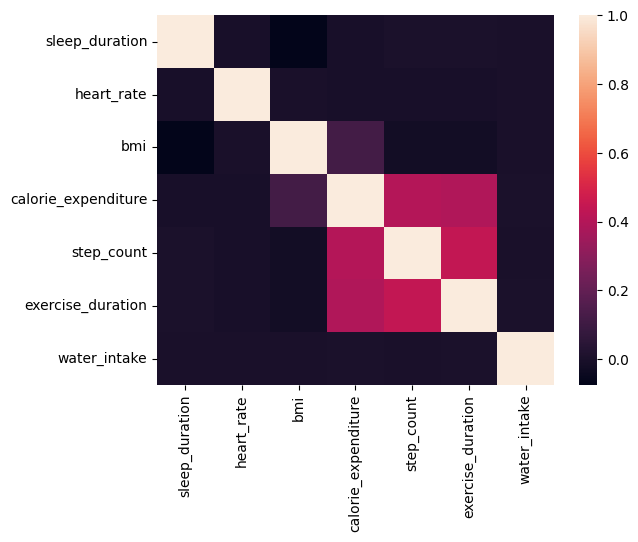

In [ ]:
cols = df.columns[df.dtypes == float]
sns.heatmap(df[cols].corr())

<Axes: xlabel='calorie_expenditure'>

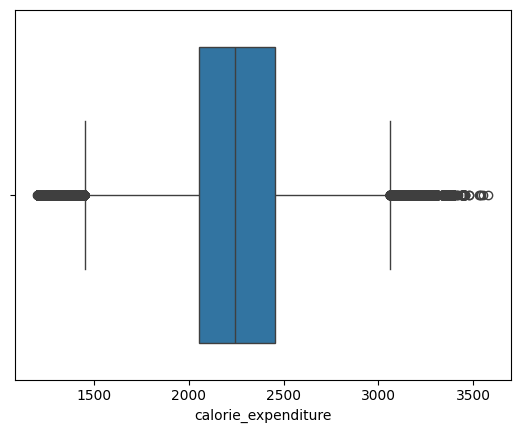

In [ ]:
# missing values
# outliers=calorie_expenditure ,exercise_duration
# imbalanced dataset
sns.boxplot(x=df["calorie_expenditure"])

<Axes: xlabel='exercise_duration'>

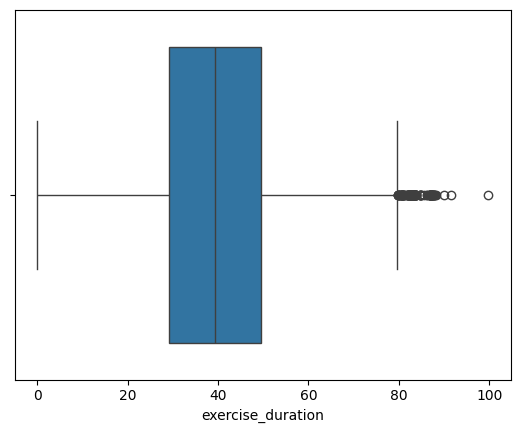

In [ ]:
sns.boxplot(x=df["exercise_duration"])

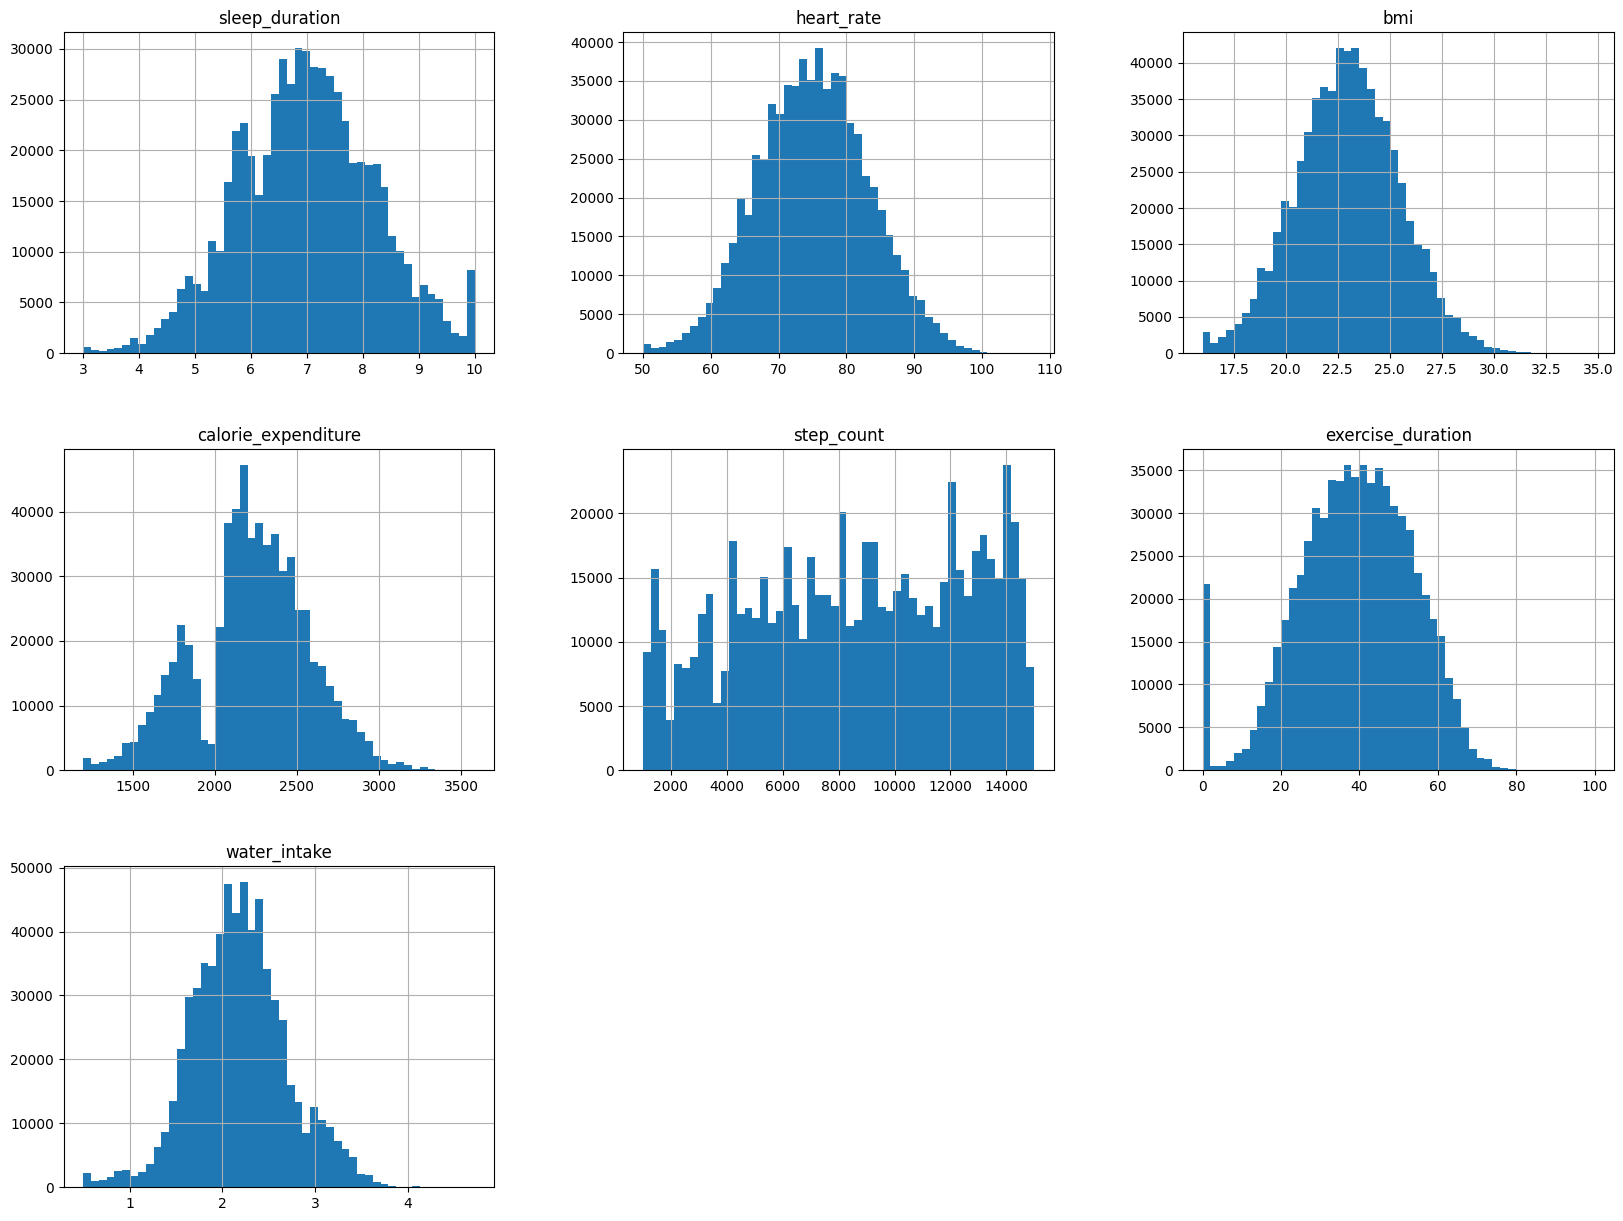

In [ ]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score ,balanced_accuracy_score ,confusion_matrix ,classification_report
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler , OrdinalEncoder , OneHotEncoder , LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [ ]:
X=df.drop("health_condition",axis=1)
y=df["health_condition"]
X

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
X_train.shape

(552070, 13)

In [ ]:
outliers_col=["calorie_expenditure","exercise_duration"]
for i in outliers_col:
    min=X_train[i].quantile(0.25)
    max=X_train[i].quantile(0.75)
    iqr=max-min
    lower=min - (1.5*iqr)
    high=max +(1.5 *iqr)
    mask = (X_train[i] > lower) & (X_train[i] < high)
    X_train = X_train[mask]
    Y_train = Y_train[mask]
X_train.shape
#outliers

(494845, 13)

In [ ]:
num_pipeline = Pipeline([
    ("si", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
])
ohe_pipeline = Pipeline([
    ("si", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder()),
])
oe_pipeline = Pipeline([
    ("si", SimpleImputer(strategy="constant",fill_value="missing")),
    ("oe", OrdinalEncoder(categories=[
        ["sedentary", "moderate", "active"],
        ["low", "medium", "high"],
        ["poor", "average", "good"]], handle_unknown="use_encoded_value", unknown_value=-1)),
])
trf = ColumnTransformer([
    ("num", num_pipeline, cols),
    ("ohe", ohe_pipeline, ["gender", "smoking_alcohol", "diet_type"]),
    ("oe", oe_pipeline, ["physical_activity_level", "stress_level", "sleep_quality"]),
], remainder="passthrough")

X_train=trf.fit_transform(X_train)
X_test=trf.transform(X_test)
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.154332,1.991305,1.576490,1.230763,-1.881346,0.699947,-0.312729,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
1,-0.002628,-0.000269,0.505239,0.456226,1.245360,0.816632,-0.710863,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0
2,1.453614,0.897169,-0.643403,0.248050,0.210811,-1.070906,1.797383,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.002628,-0.074031,-0.162766,-0.208101,-0.416447,-1.187590,-0.531703,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-1.0,1.0
4,1.601855,-0.848532,-0.399011,-0.382601,1.259610,0.960771,0.324286,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494840,-0.142149,-0.332198,0.228262,1.533842,-0.654293,0.706811,1.319622,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
494841,0.886813,-0.369079,-1.295115,-0.006047,-1.365237,-0.652216,-1.049277,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.0,2.0,0.0
494842,0.267692,0.577533,0.936998,0.382752,-1.255642,-1.750419,1.717756,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0
494843,-0.979270,-0.713302,-0.700428,0.979727,0.450470,1.283368,-0.034035,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0


In [ ]:
le=LabelEncoder()
Y_train=le.fit_transform(Y_train)
Y_test=le.transform(Y_test)

In [ ]:
lr=LogisticRegression(class_weight={0:50,1:1},n_jobs=-1)
lr.fit(X_train,Y_train)
y_pred=lr.predict(X_test)
print(balanced_accuracy_score(Y_test,y_pred))
print(classification_report(Y_test,y_pred))
# temporary model

0.3486245224431475
              precision    recall  f1-score   support

           0       0.86      1.00      0.93    118512
           1       0.00      0.00      0.00      7961
           2       0.99      0.05      0.09     11545

    accuracy                           0.86    138018
   macro avg       0.62      0.35      0.34    138018
weighted avg       0.82      0.86      0.80    138018



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def objective_rf(trial):
    params={"n_estimators":trial.suggest_int("n_estimators",100,300),
        "max_depth":trial.suggest_int("max_depth",5,30),
        "n_jobs":-1,
        "min_samples_split":trial.suggest_int("min_samples_split",2,10),
        "min_samples_leaf":trial.suggest_int("min_samples_leaf",1,5),
        "random_state":42}
    model =RandomForestClassifier(**params)
    score= np.mean(cross_val_score(model,X_train,Y_train,cv=3,n_jobs=-1,scoring="accuracy"))
    return score

study=optuna.create_study(direction="maximize")
study.optimize(objective_rf,n_trials=10)
print(study.best_params)

print("="*25)

rf= RandomForestClassifier(**study.best_params,random_state=42,n_jobs=-1)
rf.fit(X_train,Y_train)
y_pred=rf.predict(X_test)
print("accuracy score = " ,accuracy_score(Y_test,y_pred))
print("balanced accuracy score = " ,balanced_accuracy_score(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[I 2026-08-15 11:48:26,864] A new study created in memory with name: no-name-b1483c1f-23d1-4564-bcdd-aa2fd5477f7f
[I 2026-08-15 11:50:25,280] Trial 0 finished with value: 0.9615394727396337 and parameters: {'n_estimators': 256, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9615394727396337.
[I 2026-08-15 11:52:04,454] Trial 1 finished with value: 0.9650779537595621 and parameters: {'n_estimators': 146, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9650779537595621.
[I 2026-08-15 11:53:28,026] Trial 2 finished with value: 0.9554911100012996 and parameters: {'n_estimators': 207, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9650779537595621.
[I 2026-08-15 11:56:26,354] Trial 3 finished with value: 0.9649223492139879 and parameters: {'n_estimators': 276, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 1 with value: 

{'n_estimators': 276, 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 2}
accuracy score =  0.9662870060426901
balanced accuracy score =  0.8637724896897416
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    118512
           1       0.93      0.82      0.88      7961
           2       0.98      0.77      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.91    138018
weighted avg       0.97      0.97      0.96    138018



In [ ]:
def objective_xg(trial):
    params={"n_estimators":trial.suggest_int("n_estimators",100,400),
            "lambda": trial.suggest_float('lambda', 1e-8, 1.0, log=True),
            "alpha": trial.suggest_float('alpha', 1e-8, 1.0, log=True),
            "gamma": trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'eta': trial.suggest_float('eta', 0.01, 0.3),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.4, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0)}

    model=XGBClassifier(**params ,random_state=42,n_jobs=-1)
    score=np.mean(cross_val_score(model,X_train,Y_train,cv=3,n_jobs=-1,scoring="accuracy"))
    return score

study_xg=optuna.create_study(direction="maximize")
study_xg.optimize(objective_xg,n_trials=20)
print(study_xg.best_params)

print("="*25)

xg=XGBClassifier(**study_xg.best_params,random_state=42,n_jobs=-1)
xg.fit(X_train,Y_train)
y_pred=xg.predict(X_test)
print(balanced_accuracy_score(Y_test,y_pred))
print(accuracy_score(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[I 2026-08-15 12:11:39,027] A new study created in memory with name: no-name-f8a73b7e-da85-4c33-8d97-10a93a1685d3
[I 2026-08-15 12:12:15,866] Trial 0 finished with value: 0.9662237668990397 and parameters: {'n_estimators': 299, 'lambda': 2.8004018856012813e-08, 'alpha': 8.855797142041803e-07, 'gamma': 0.0019935234932409404, 'eta': 0.1183116799663101, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.6814236705536474, 'colsample_bytree': 0.42153794982030224}. Best is trial 0 with value: 0.9662237668990397.
[I 2026-08-15 12:12:42,665] Trial 1 finished with value: 0.9663066211220377 and parameters: {'n_estimators': 258, 'lambda': 9.551050600902514e-06, 'alpha': 0.0002224197349695369, 'gamma': 0.12056262269751215, 'eta': 0.1937343277743845, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.4567670023445097, 'colsample_bytree': 0.6456108767118595}. Best is trial 1 with value: 0.9663066211220377.
[I 2026-08-15 12:13:17,956] Trial 2 finished with value: 0.9665632671955997 and paramet

{'n_estimators': 229, 'lambda': 0.38313139532905555, 'alpha': 2.9009038922298646e-06, 'gamma': 0.011206635471599873, 'eta': 0.07141730934273183, 'max_depth': 5, 'min_child_weight': 1, 'subsample': 0.8559000642376968, 'colsample_bytree': 0.5218553069037731}
0.8741847651428688
0.9671709487168341
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    118512
           1       0.93      0.83      0.88      7961
           2       0.96      0.80      0.87     11545

    accuracy                           0.97    138018
   macro avg       0.95      0.87      0.91    138018
weighted avg       0.97      0.97      0.97    138018



In [ ]:
# submission
test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
X_test=test.drop("id",axis=1)
X_test=trf.transform(X_test)
Y_pred=xg.predict(X_test)
Y_pred=le.inverse_transform(Y_pred)

In [ ]:
submission=pd.DataFrame({"id": test["id"],"health_condition":Y_pred})
submission.to_csv('submission.csv', index=False)

In [ ]:
print(Y_pred)

[2 0 0 ... 0 0 2]


In [ ]:
Y_pred = xg.predict(X_test)
print(Y_pred[:5])
Y_pred = le.inverse_transform(Y_pred)
print(Y_pred[:5])
print(type(Y_pred[0]))

[2 0 0 0 2]
['unhealthy' 'at-risk' 'at-risk' 'at-risk' 'unhealthy']
<class 'str'>


In [ ]:
submission_df = pd.read_csv('submission.csv')
print(submission_df.head(10))
print("\nPrediction Counts:")
print(submission_df['health_condition'].value_counts())

       id  health_condition
0  690088                 2
1  690089                 0
2  690090                 0
3  690091                 0
4  690092                 2
5  690093                 0
6  690094                 0
7  690095                 0
8  690096                 0
9  690097                 0

Prediction Counts:
health_condition
0    260313
2     20192
1     15248
Name: count, dtype: int64
